# Desafio Ciência e Governança de Dados

Desenvolvido por Estevão Augusto da Fonseca Santos, Graduando em Ciência de Computação

6° Período da Universidade Federal de Lavras

## Objetivos

Após a coleta e o pré-processamento dos dados, inicia-se a Análise Exploratória, etapa em que o conjunto de dados é investigado, compreendido e resumido antes da aplicação de modelos ou da obtenção de conclusões definitivas

In [1]:
import pandas as pd                     # Biblioteca para manipulação e análise de dados
import matplotlib.pyplot as plt         # Biblioteca para criação de gráficos 2D
import seaborn as sns                   # Biblioteca para visualização estatística de dados
import os                               # Biblioteca para interação com o sistema de arquivos e diretórios
import numpy as np                      # Biblioteca para calculo para vetores e matrizes

In [2]:
import sys                              # 
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))  # Adiciona raiz

# Define constantes que armazenam os caminhos que serão utilizados neste notebook
from config_path import RAW_DATA_DIRECTORY_PATH, PROCESSED_DATA_DIRECTORY_PATH, REPORTS_DIRECTORY_PATH

In [ ]:
# Caso a pasta 'reports' tenha sido excluida, o notebook cria ela

if not os.path.isdir(REPORTS_DIRECTORY_PATH):
    os.mkdir(REPORTS_DIRECTORY_PATH)

## Análise Exploratória

In [3]:
# 

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Carregar dados

In [5]:
df_municipios = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/tamanho_populacional_mun.csv")
df_alfabetizacao = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/alfabetizacao_processada.csv")
df_educacao = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/educacao_basica_sexo_raca_cor.csv")
df_total_matriculas = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/quantidade_total_matriculas_alfabetizacao_dividida_mun.csv")
df_indice_gini = pd.read_csv(f"{RAW_DATA_DIRECTORY_PATH}/indice_de_gini_uf.csv")
df_uf = pd.read_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/tamanho_populacional_uf.csv")

In [ ]:
# Selecionar apenas as colunas relevantes de cada DataFrame
# df_pib_mun = df_pib_mun[['id_municipio','pib','valor_adicionado_precos_correntes_total']]  # PIB e Valor Adicionado por município
df_alfabetizacao = df_alfabetizacao[['id_municipio','nome_municipio','total_alfabetizados']]  # Total de alfabetizados por município
# df_municipios = df_municipios[['id_municipio','id_municipio_nome','populacao_total','NM_UF_SIGLA','NM_UF','AR_MUN_2024','ano']]  # Informações gerais dos municípios
df_matriculas = df_educacao.groupby(['ano','id_municipio','id_municipio_nome'])['quantidade_matricula'].sum().reset_index()  # Soma das matrículas por município

# Merge sequencial dos DataFrames, combinando informações pelos IDs dos municípios
df = df_municipios.merge(df_alfabetizacao, on=['id_municipio'], how='inner')  # Adiciona dados de alfabetização
df = df.merge(df_matriculas, on=['id_municipio','ano'], how='inner')  # Adiciona dados de matrículas
df.rename(columns={ 'id_municipio_nome_x' : 'id_municipio_nome'}, inplace=True)
df.drop('id_municipio_nome_y', axis=1, inplace=True)
# df = df.merge(df_pib_mun, on='id_municipio', how='inner')  # Adiciona dados de PIB

# -------------------------------
# Criar colunas normalizadas (antes de qualquer análise)
# -------------------------------
# Evitar divisão por zero caso populacao_total tenha zeros
df['pib_per_capita'] = df['pib'] / df['populacao_total']
df['va_per_capita'] = df['valor_adicionado_precos_correntes_total'] / df['populacao_total']
df['taxa_alfabetizacao'] = df['total_alfabetizados'] / df['populacao_total']
df['taxa_matricula'] = df['quantidade_matricula'] / df['populacao_total']

# Conferir se as colunas foram criadas corretamente
print(df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula']].head())

In [ ]:
df

In [46]:
print("## 1. Visão Geral e Estatísticas Descritivas")
# Informações básicas do DataFrame
print("\n--- Informações do DataFrame ---")
df_uf.info()
df_alfabetizacao.info()
df_educacao.info()
df_municipios.info()

# Estatísticas descritivas para colunas numéricas
print("\n--- Estatísticas Descritivas ---")
print(df_uf.describe())

## 1. Visão Geral e Estatísticas Descritivas

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 15 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   ano                                                               135 non-null    int64  
 1   id_uf                                                             135 non-null    int64  
 2   id_uf_sigla                                                       135 non-null    object 
 3   id_uf_nome                                                        135 non-null    object 
 4   sigla_uf                                                          135 non-null    object 
 5   sigla_uf_nome                                                     135 non-null    object 
 6   pib                                                

### Filtrar Lavras

Realizaremos uma análise exploratória a partir de Lavras no ano de 2020. Nele iremos realizar algumas comparações e aprender alguns detalhes sobre esse múnicipio, e como ele se compara em relação a outros. Como tambem informações estaduais.

In [47]:
lavras_pop_2020 = df_municipios.loc[df_municipios['id_municipio_nome'] == 'Lavras']
lavras_pop_2020 = lavras_pop_2020.loc[lavras_pop_2020['ano'] == 2020]
lavras_alf = df_alfabetizacao[df_alfabetizacao['nome_municipio'] == 'Lavras (MG)'] # alfabetização é do ano de 2022
lavras_edu = df_educacao[df_educacao['id_municipio_nome'] == 'Lavras']
# lavras_pib = df_municipios[df_municipios['id_municipio_nome'] == 'Lavras']

### Indicadores de Lavras - Ano 2020

In [48]:
quant_pop_lavras_2020 = lavras_pop_2020['populacao_total'].values[0]
total_alfabetizados = lavras_alf['total_alfabetizados'].values[0]
total_nao_alfabetizados = lavras_alf['total_nao_alfabetizados'].values[0]
tamanho_lavras = lavras_pop_2020['AR_MUN_2024'].values[0]
total_matriculas = lavras_edu['quantidade_matricula'].sum()
pib = lavras_pop_2020['pib'].values[0]
va_total = lavras_pop_2020['valor_adicionado_precos_correntes_total'].values[0]
taxa_alfabetizacao = total_alfabetizados / quant_pop_lavras_2020

print(f"Dados do Múnicipio de Lavras (Minas Gerais) em 2020:")
print(f"Populacao Lavras: {quant_pop_lavras_2020} habitantes")
print(f"Densidade Populacional: {(quant_pop_lavras_2020 / tamanho_lavras):.5f} habs/km2")
print(f"Total Não Alfabetizados {total_nao_alfabetizados}")
print(f"Total Alfabetizados: {total_alfabetizados}")
print(f"Total Alfabetizados e Nao Alfabetizados: {total_alfabetizados + total_nao_alfabetizados}")
print(f"Taxa Alfabetização: {(taxa_alfabetizacao * 100):.2f}%")
print(f"Total Matriculas: {total_matriculas}")
print(f"Pib total: {pib / 1_000_000} milhoes")
print(f"Valor bruto total: {va_total / 1_000_000} milhoes")

Dados do Múnicipio de Lavras (Minas Gerais) em 2020:
Populacao Lavras: 104783 habitantes
Densidade Populacional: 185.54071 habs/km2
Total Não Alfabetizados 2214
Total Alfabetizados: 84909
Total Alfabetizados e Nao Alfabetizados: 87123
Taxa Alfabetização: 81.03%
Total Matriculas: 111466
Pib total: 2677.947 milhoes
Valor bruto total: 2365.365 milhoes


### Indicadores do estado de MG - Ano 2020

In [49]:
# Vamos utilizar o estado de MG no ano de 2020 como indicador mais recente
df_mg = df_municipios.loc[df_municipios['NM_UF_SIGLA'] == 'MG']
df_mg = df_mg.loc[df_mg['ano'] == 2020]


In [50]:
# Calcular a quantidade total de habitantes em MG no ano de 2020
pop_mg = df_mg['populacao_total'].sum()
tamanho_km2_mg = df_mg['AR_MUN_2024'].sum()
densidade_populacional_mg = pop_mg / tamanho_km2_mg
proporcao_pop = (quant_pop_lavras_2020 / pop_mg) * 100

# Taxa de alfabetização de todos os municípios de MG
df_mg_alf = df_alfabetizacao.merge(df_mg, on=['id_municipio'], how="inner")
df_mg_alf.drop(columns={ 'nome_municipio' }, inplace=True)
df_mg_alf['taxa_alfabetizacao'] = (df_mg_alf['total_alfabetizados'] / df_mg_alf['populacao_total']) * 100

# Total Nao Alfabetizados e Alfabetizados MG
alfabetizados_mg = df_mg_alf['total_alfabetizados'].sum()
nao_alfabetizados_mg = df_mg_alf['total_nao_alfabetizados'].sum()

# Ranking de Lavras em MG
rank_alf_mg['taxa_alfabetizacao'] = df_mg_alf['taxa_alfabetizacao'].rank(ascending=False)[df_mg_alf['id_municipio'] == 3138203]
rank_pop_mg['populacao_total'] = df_mg['populacao_total'].rank(ascending=False)[df_mg['id_municipio'] == 3138203]


print("Informações em Minas Gerais:")
print(f"Quantidade total de habitantes: {pop_mg} habitantes")
print(f"Total Alfabetizados MG: {alfabetizados_mg}")
print(f"Total Não Alfabetizados MG: {nao_alfabetizados_mg}")
print(f"Total Alfabetizados e Nao Alfabetizados MG: {nao_alfabetizados_mg + alfabetizados_mg}")
print(f"Taxa de Alfabetização Geral MG: {((alfabetizados_mg / (nao_alfabetizados_mg + alfabetizados_mg)) * 100):.2f}%")
print(f"Ranking de alfabetização em MG: {rank_alf_mg['taxa_alfabetizacao'].values[0]}")
print(f"Ranking populacional de MG: {rank_pop_mg['populacao_total'].values[0]}")

Informações em Minas Gerais:
Quantidade total de habitantes: 21292666 habitantes
Total Alfabetizados MG: 15847064
Total Não Alfabetizados MG: 985006
Total Alfabetizados e Nao Alfabetizados MG: 16832070
Taxa de Alfabetização Geral MG: 94.15%
Ranking de alfabetização em MG: 98.0
Ranking populacional de MG: 33.0


### Ranking Brasil

In [51]:
df_municipios_2020 = df_municipios.loc[df_municipios["ano"] == 2020, :]
df_brasil = df_municipios_2020.merge(df_alfabetizacao, on=['id_municipio', 'id_municipio'])
df_brasil['taxa_alfabetizacao'] = df_brasil['total_alfabetizados'] / df_brasil['populacao_total'] * 100

rank_alf_brasil = df_brasil['taxa_alfabetizacao'].rank(ascending=False)[df_brasil['id_municipio'] == lavras_pop_2020['id_municipio'].values[0]].values[0]
rank_pop_brasil = df_brasil['populacao_total'].rank(ascending=False)[df_brasil['id_municipio'] == lavras_pop_2020['id_municipio'].values[0]].values[0]

print(f"Rank de alfabetização do Brasil: {rank_alf_brasil}")
print(f"Rank populacional do Brasil: {rank_pop_brasil}")

del df_municipios_2020

Rank de alfabetização do Brasil: 749.0
Rank populacional do Brasil: 309.0


### Indicadores Lavras

In [52]:
indicadores_lavras = pd.DataFrame({
    'id_municipio': [lavras_pop_2020['id_municipio'].values[0]],
    'municipio': ['Lavras'],
    'populacao_total': [lavras_pop_2020['populacao_total'].values[0]],
    'total_alfabetizados': [total_alfabetizados],
    'taxa_alfabetizacao': [taxa_alfabetizacao],
    'total_matriculas': [total_matriculas],
    'pib_milhoes': [pib],
    'va_total_milhoes': [va_total],
    'populacao_estado_mg': [pop_mg],
    'proporcao_pop_estado_mg': [proporcao_pop],
    'rank_alfabetizacao_mg': [rank_alf_mg['taxa_alfabetizacao'].values[0]],
    'rank_populacao_mg': [rank_pop_mg['populacao_total'].values[0]],
    'rank_alfabetizacao_brasil': [rank_alf_brasil],
    'rank_populacao_brasil': [rank_pop_brasil]
})

indicadores_lavras.to_csv(f"{PROCESSED_DATA_DIRECTORY_PATH}/indicadores_lavras_completo.csv", index=False)
print(indicadores_lavras)

   id_municipio municipio  populacao_total  total_alfabetizados  \
0       3138203    Lavras           104783                84909   

   taxa_alfabetizacao  total_matriculas  pib_milhoes  va_total_milhoes  \
0            0.810332            111466   2677947000        2365365000   

   populacao_estado_mg  proporcao_pop_estado_mg  rank_alfabetizacao_mg  \
0             21292666                 0.492108                   98.0   

   rank_populacao_mg  rank_alfabetizacao_brasil  rank_populacao_brasil  
0               33.0                      749.0                  309.0  


## Gráficos Comparativos

#### 1. Taxa de alfabetização de Lavras vs MG - 2020

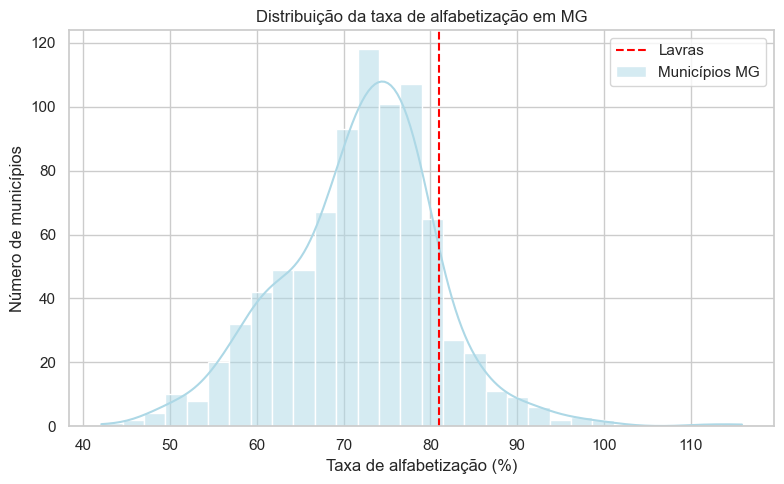

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(
    df_mg_alf['taxa_alfabetizacao'],
    bins=30,
    kde=True,
    color='lightblue',
    label='Municípios MG'
)
plt.axvline(taxa_alfabetizacao * 100, color='red', linestyle='--', label='Lavras')
plt.title('Distribuição da taxa de alfabetização em MG em 2020')
plt.xlabel('Taxa de alfabetização (%)')
plt.ylabel('Número de municípios')
plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'taxa_alfabetizacao_lavras_vs_mg.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()  # fecha a figura para não mostrar

#### 2. População de Lavras vs top 10 municípios MG - 2020

C:\Users\Maurício\AppData\Local\Temp\ipykernel_13768\1206640397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


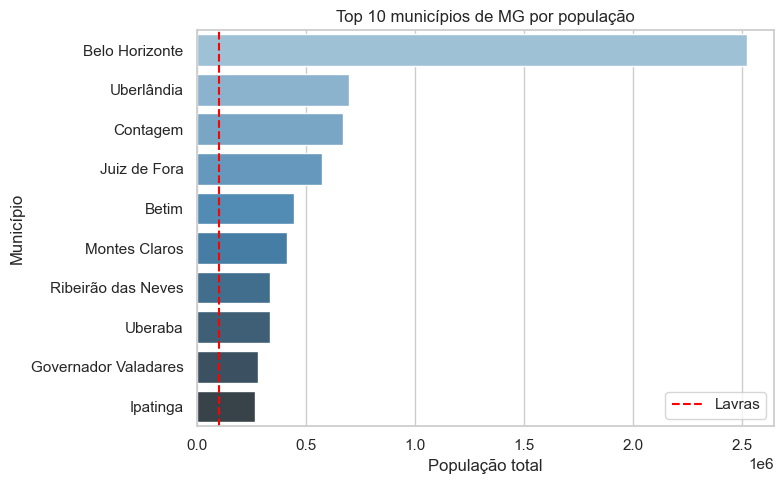

In [ ]:
top10_pop_mg = df_mg.sort_values('populacao_total', ascending=False).head(10)

# Criar lista de cores para cada barra
cores = sns.color_palette("Blues_d", n_colors=len(top10_pop_mg))

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10_pop_mg,
    x='populacao_total',
    y='id_municipio_nome',
    palette=cores
)
plt.axvline(quant_pop_lavras_2020, color='red', linestyle='--', label='Lavras')
plt.title('Top 10 municípios de MG por população em 2020')
plt.xlabel('População total')
plt.ylabel('Município')
plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'pop_lavras_vs_top10_mun_mg.png'), dpi=300, bbox_inches='tight')


plt.show()
plt.close()

#### 3. PIB vs Valor Adicionado de Lavras

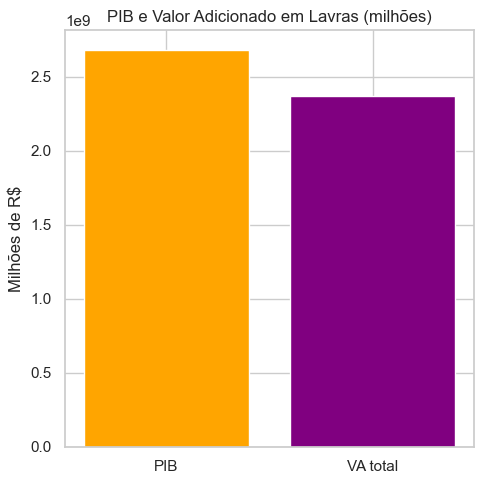

In [55]:
plt.figure(figsize=(5,5))
plt.bar(['PIB', 'VA total'], [pib, va_total], color=['orange','purple'])
plt.title('PIB e Valor Adicionado em Lavras (milhões)')
plt.ylabel('Milhões de R$')
plt.tight_layout()
plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'pib_vs_valor_adicionado_em_lavras.png'), dpi=300, bbox_inches='tight')


plt.show()
plt.close()

### 4. Grafico do Indice de Gini

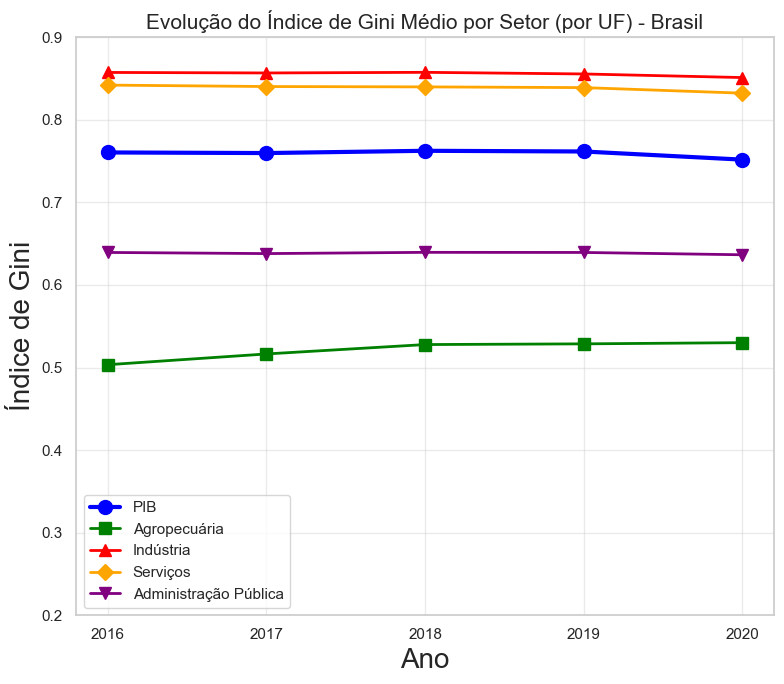

<Figure size 1000x600 with 0 Axes>

In [56]:
df_aux = df_indice_gini.groupby(['ano']).mean()

anos = df_aux.index.array


plt.figure(figsize=(8, 7))
plt.plot(anos, df_aux['gini_pib'], marker='o', linewidth=3, markersize=10, label='PIB', color='blue')
plt.plot(anos, df_aux['gini_va_agro'], marker='s', linewidth=2, markersize=8, label='Agropecuária', color='green')
plt.plot(anos, df_aux['gini_va_industria'], marker='^', linewidth=2, markersize=8, label='Indústria', color='red')
plt.plot(anos, df_aux['gini_va_servicos'], marker='D', linewidth=2, markersize=8, label='Serviços', color='orange')
plt.plot(anos, df_aux['gini_va_adespss'], marker='v', linewidth=2, markersize=8, label='Administração Pública', color='purple')

plt.title('Evolução do Índice de Gini Médio por Setor (por UF) - Brasil', fontsize=15)
plt.xlabel('Ano', fontsize=20)
plt.ylabel('Índice de Gini', fontsize=20)
plt.legend()
plt.grid(True, alpha=0.4)
plt.ylim(0.2, 0.9)
plt.xticks(anos.astype(int)) 
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'grafico_evo_indice_gini_medio_por_setor.png'), dpi=300, bbox_inches='tight')

del anos

### 5. Correlação de Indicadores Socioeconomicos entre todos os Municipios do Brasil entre 2016 a 2020

In [ ]:
# Calcular a matriz de correlação entre os indicadores selecionados
corr_matrix = df[['pib_per_capita','va_per_capita','taxa_alfabetizacao','taxa_matricula', 'impostos_liquidos', 'pib']].corr()
print("Matriz de correlação:\n", corr_matrix)  # Exibir a matriz no console

# Criar um heatmap da matriz de correlação usando Seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')  # Heatmap com valores anotados e cores 'coolwarm'
plt.title('Correlação entre indicadores socioeconômicos')  # Título do gráfico

# Salvar a figura em alta resolução no diretório especificado
# plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'matriz_correlacao_mun_brasil_2016_a_2020.png'), dpi=300, bbox_inches='tight')

plt.show()   # Exibir o gráfico
plt.close()  # Fechar a figura para liberar memória

### 6. Correlação de Indicadores Socioeconomicos do municipio de Lavras entre 2016 a 2020

#### 6. Comparação do total de matriculas entre Lavras e os 10 municipios com maior quantidade de matriculas no ano de 2020

In [14]:
df_aux.values

array([[1100015, "Alta Floresta D'Oeste", 5489],
       [1100023, 'Ariquemes', 26128],
       [1100031, 'Cabixi', 1416],
       ...,
       [5222203, 'Vila Boa', 1283],
       [5222302, 'Vila Propício', 1337],
       [5300108, 'Brasília', 675484]], shape=(5570, 3), dtype=object)

In [16]:
df = df_total_matriculas[df_total_matriculas['ano'] == 2020].reset_index()
df.drop(columns={"index"},inplace=True)
df_aux = df.groupby(['id_municipio', 'id_municipio_nome'], as_index=False)['total_matriculas'].sum()
df_aux = pd.DataFrame(data=df_aux, columns={"id_municipio", "id_municipio_nome", "matriculas_total"})
df_total_matriculas_2020 = df_aux['matriculas_total'].rank(ascending=False).head(10)


df_total_matriculas_2020

ValueError: columns cannot be a set

In [6]:
top10_matriculas_mg_2020

,id_municipio,id_municipio_nome,etapa_ensino,sexo,ano,total_matriculas
0,501255.5,492435.5,473450.5,375975.5,451170.5,319526.5
1,501255.5,492435.5,473450.5,375975.5,350910.5,334415.0
2,501255.5,492435.5,473450.5,375975.5,250650.5,326757.0
3,501255.5,492435.5,473450.5,375975.5,150390.5,316048.5
4,501255.5,492435.5,473450.5,375975.5,50130.5,314375.0
5,501255.5,492435.5,473450.5,125325.5,451170.5,269171.0
6,501255.5,492435.5,473450.5,125325.5,350910.5,285091.0
7,501255.5,492435.5,473450.5,125325.5,250650.5,283632.0
8,501255.5,492435.5,473450.5,125325.5,150390.5,296776.0
9,501255.5,492435.5,473450.5,125325.5,50130.5,287927.0


In [ ]:

top10_pop_mg = df_mg.sort_values('populacao_total', ascending=False).head(10)

# Criar lista de cores para cada barra
cores = sns.color_palette("Blues_d", n_colors=len(top10_pop_mg))

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10_pop_mg,
    x='populacao_total',
    y='id_municipio_nome',
    palette=cores
)
plt.axvline(quant_pop_lavras_2020, color='red', linestyle='--', label='Lavras')
plt.title('Top 10 municípios de MG por população')
plt.xlabel('População total')
plt.ylabel('Município')
plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(f"{REPORTS_DIRECTORY_PATH}/", 'pop_lavras_vs_top10_mun_mg.png'), dpi=300, bbox_inches='tight')


plt.show()
plt.close()

#### 7. 